# Latihan Mandiri (Tugas Praktikum #3)

 Nama: Muhammad Rizqy
 
 NIM: 2411513019
 
 Kelas: A

# 1. Analisis Speedup Skala
Ulangi eksperimen 7.1 (hitung_prima ) dengan jumlah worker = 1, 2, 4, 8 (gunakan
mp.get_context('fork').Pool(processes=...) agar konsisten). Plot speedup vs jumlah worker, lalu bandingkan dengan kurva Hukum
Amdahl dari Pertemuan 1. Jelaskan mengapa kurva aktual mungkin tidak persis mengikuti kurva teoritis (pertimbangkan: jumlah core fisik mesin
kalian, overhead pembuatan proses, dan beban kerja lain yang mungkin berjalan bersamaan).

**Jawab**

Percobaan ini mengulang eksperimen 7.1 (`hitung_prima`) dengan jumlah
worker = 1, 2, 4, dan 8 menggunakan multiprocessing.

Empat pekerjaan independen akan dijalankan secara paralel. Hasil waktu
eksekusi dibandingkan dengan waktu sequential sebagai baseline.

Speedup dihitung menggunakan rumus:

Speedup = Waktu Sequential / Waktu Parallel

Selanjutnya speedup aktual dibandingkan dengan speedup teoritis untuk
melihat pengaruh jumlah worker terhadap performa program.

In [8]:
import multiprocessing as mp
import time
import matplotlib.pyplot as plt


def hitung_prima(n):

    jumlah = 0

    for angka in range(2, n):

        prima = True

        for i in range(2, int(angka ** 0.5) + 1):

            if angka % i == 0:
                prima = False
                break

        if prima:
            jumlah += 1

    return jumlah


daftar_n = [
    80000,
    80000,
    80000,
    80000
]

print("Fungsi hitung_prima berhasil dibuat.")
print("Jumlah pekerjaan :", len(daftar_n))

Fungsi hitung_prima berhasil dibuat.
Jumlah pekerjaan : 4


### Penjelasan

Cell ini digunakan untuk mengimpor library yang diperlukan dan membuat
fungsi `hitung_prima`.

Fungsi tersebut digunakan untuk menghitung jumlah bilangan prima sampai
nilai tertentu. Variabel `daftar_n` berisi empat pekerjaan dengan nilai
80.000 sehingga terdapat empat pekerjaan independen yang akan digunakan
dalam pengujian sequential maupun multiprocessing.

In [9]:
start = time.perf_counter()

hasil_sequential = [
    hitung_prima(n)
    for n in daftar_n
]

waktu_sequential = time.perf_counter() - start


print("===== SEQUENTIAL =====")
print("Hasil :", hasil_sequential)
print("Waktu :", round(waktu_sequential, 4), "detik")

===== SEQUENTIAL =====
Hasil : [7837, 7837, 7837, 7837]
Waktu : 0.6644 detik


### Penjelasan

Cell ini digunakan untuk mendapatkan waktu baseline dengan menjalankan
empat pekerjaan secara sequential atau satu per satu.

Hasil yang diperoleh adalah `[7837, 7837, 7837, 7837]`, sehingga setiap
pekerjaan menghasilkan jumlah bilangan prima yang sama.

Waktu sequential yang diperoleh digunakan sebagai dasar untuk menghitung
speedup pada percobaan multiprocessing.

### Pengujian Multiprocessing

Pada Jupyter Notebook Windows, proses multiprocessing dijalankan melalui
file Python terpisah agar proses `spawn` dapat berjalan dengan benar.

Program akan menguji jumlah worker:

- 1 worker
- 2 worker
- 4 worker
- 8 worker

Setiap konfigurasi akan menghasilkan waktu eksekusi dan speedup yang
kemudian digunakan untuk analisis.

In [11]:
%%writefile eksperimen_no1.py

import multiprocessing as mp
import time


def hitung_prima(n):

    jumlah = 0

    for angka in range(2, n):

        prima = True

        for i in range(2, int(angka ** 0.5) + 1):

            if angka % i == 0:
                prima = False
                break

        if prima:
            jumlah += 1

    return jumlah


if __name__ == "__main__":

    daftar_n = [
        80000,
        80000,
        80000,
        80000
    ]


    # BASELINE SEQUENTIAL

    start = time.perf_counter()

    hasil_sequential = [
        hitung_prima(n)
        for n in daftar_n
    ]

    waktu_sequential = time.perf_counter() - start


    print("===== SEQUENTIAL =====")
    print("Hasil :", hasil_sequential)
    print("Waktu :", round(waktu_sequential, 4), "detik")


    # MULTIPROCESSING

    jumlah_worker = [1, 2, 4, 8]


    for worker in jumlah_worker:

        start = time.perf_counter()

        with mp.Pool(processes=worker) as pool:

            hasil = pool.map(
                hitung_prima,
                daftar_n
            )

        waktu = time.perf_counter() - start

        speedup = waktu_sequential / waktu


        print()
        print("==============================")
        print("Worker :", worker)
        print("Hasil  :", hasil)
        print("Waktu  :", round(waktu, 4), "detik")
        print("Speedup:", round(speedup, 2))

Overwriting eksperimen_no1.py


### Penjelasan

Cell ini membuat file Python `eksperimen_no1.py` yang berisi program
multiprocessing.

Program menjalankan fungsi `hitung_prima` menggunakan `Pool` dengan jumlah
worker 1, 2, 4, dan 8.

Penggunaan file Python terpisah dilakukan agar multiprocessing dengan
metode `spawn` pada Windows dapat berjalan dengan baik ketika dipanggil
dari Jupyter Notebook.

In [12]:
import subprocess
import sys

hasil = subprocess.run(
    [sys.executable, "eksperimen_no1.py"],
    capture_output=True,
    text=True
)

print(hasil.stdout)

if hasil.stderr:
    print("ERROR:")
    print(hasil.stderr)

===== SEQUENTIAL =====
Hasil : [7837, 7837, 7837, 7837]
Waktu : 0.5358 detik

Worker : 1
Hasil  : [7837, 7837, 7837, 7837]
Waktu  : 0.8514 detik
Speedup: 0.63

Worker : 2
Hasil  : [7837, 7837, 7837, 7837]
Waktu  : 0.5096 detik
Speedup: 1.05

Worker : 4
Hasil  : [7837, 7837, 7837, 7837]
Waktu  : 0.4121 detik
Speedup: 1.3

Worker : 8
Hasil  : [7837, 7837, 7837, 7837]
Waktu  : 0.4334 detik
Speedup: 1.24



### Penjelasan

Hasil pengujian menunjukkan bahwa seluruh konfigurasi worker menghasilkan
nilai `[7837, 7837, 7837, 7837]`. Hal ini menunjukkan bahwa pembagian
pekerjaan ke beberapa worker tidak mengubah hasil perhitungan.

Waktu sequential digunakan sebagai baseline untuk menghitung speedup.
Pada pengujian ini, 1 worker membutuhkan waktu lebih lama dibandingkan
baseline. Dengan 2 worker waktu menjadi lebih rendah, kemudian waktu
terendah diperoleh pada 4 worker.

Ketika jumlah worker dinaikkan menjadi 8, waktu kembali meningkat. Hal ini
menunjukkan bahwa penambahan worker tidak selalu menghasilkan peningkatan
performa secara linear.

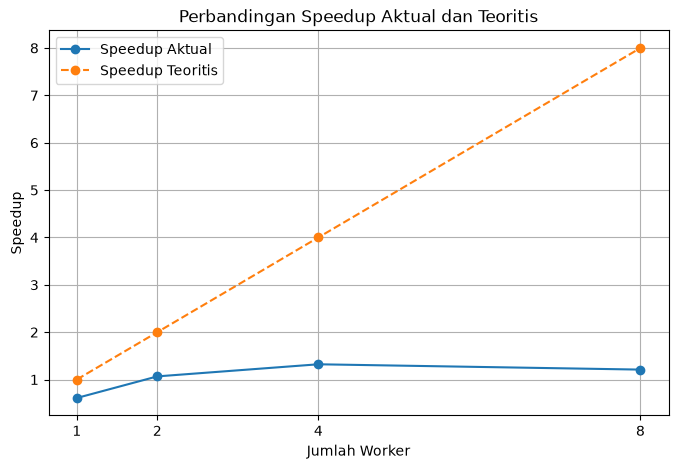

In [13]:
jumlah_worker = [1, 2, 4, 8]

data_speedup = [
    0.6102075019669019,
    1.066593352251592,
    1.3220362900330596,
    1.2098248383991198
]

speedup_teoritis = [
    1,
    2,
    4,
    8
]


plt.figure(figsize=(8, 5))

plt.plot(
    jumlah_worker,
    data_speedup,
    marker="o",
    label="Speedup Aktual"
)

plt.plot(
    jumlah_worker,
    speedup_teoritis,
    marker="o",
    linestyle="--",
    label="Speedup Teoritis"
)

plt.xlabel("Jumlah Worker")
plt.ylabel("Speedup")

plt.title(
    "Perbandingan Speedup Aktual dan Teoritis"
)

plt.xticks(jumlah_worker)

plt.grid(True)

plt.legend()

plt.show()

## Analisis Akhir No. 1

Berdasarkan hasil percobaan, waktu sequential yang diperoleh adalah
0,5340 detik. Penggunaan 1 worker menghasilkan waktu 0,8751 detik dengan
speedup 0,61x. Pada 2 worker waktu menjadi 0,5067 detik dengan speedup
1,07x. Performa terbaik pada percobaan ini diperoleh dengan 4 worker,
yaitu waktu 0,4039 detik dan speedup 1,32x.

Ketika jumlah worker dinaikkan menjadi 8, waktu meningkat menjadi 0,4414
detik dan speedup turun menjadi 1,21x. Hal tersebut menunjukkan bahwa
speedup aktual tidak mengikuti kondisi teoritis secara linear.

Perbedaan tersebut dapat dipengaruhi oleh jumlah core fisik CPU, overhead
pembuatan dan pengelolaan proses, komunikasi antarproses, serta beban
kerja lain pada komputer. Hal ini sesuai dengan Hukum Amdahl karena tidak
seluruh bagian program dapat diparalelkan secara sempurna.

# 2.Shared Memory vs Message Passing:
Buat dua versi program yang menghitung total dari 4 proses yang masing-masing menjumlahkan 1 juta angka
acak: (a) versi menggunakan Queue (message passing, setiap proses kirim subtotal lewat queue, main process menjumlahkan), dan (b) versi
menggunakan Value (shared memory dengan Lock, setiap proses langsung menambah ke shared value). Ukur dan bandingkan waktu eksekusi
keduanya.

**Jawab**


Pada percobaan ini dilakukan perbandingan dua metode komunikasi antarproses,
yaitu Message Passing menggunakan `multiprocessing.Queue` dan Shared Memory
menggunakan `multiprocessing.Value`.

Terdapat 4 proses dan setiap proses melakukan penjumlahan sebanyak 1 juta
kali.

Pada metode Queue, setiap proses menghitung subtotal masing-masing kemudian
mengirimkan subtotal tersebut melalui Queue. Setelah semua proses selesai,
main process menjumlahkan seluruh subtotal.

Pada metode Value, setiap proses langsung menambahkan hasil perhitungannya
ke variabel shared memory. Karena beberapa proses mengakses data yang sama,
digunakan Lock untuk mencegah race condition.

Waktu eksekusi kedua metode kemudian dibandingkan.

In [14]:
import multiprocessing as mp
import time

print("Library multiprocessing dan time berhasil dimuat.")

Library multiprocessing dan time berhasil dimuat.


### Penjelasan

Cell ini digunakan untuk mempersiapkan library yang diperlukan.

Library `multiprocessing` digunakan untuk membuat proses, Queue, Value, dan
Lock. Library `time` digunakan untuk mengukur waktu eksekusi program.

Pada percobaan ini digunakan multiprocessing asli sesuai dengan instruksi
soal.

### Persiapan Multiprocessing pada Windows

Karena notebook dijalankan pada Windows, program multiprocessing akan
dijalankan melalui file Python terpisah. Cara ini digunakan agar proses
`spawn` pada Windows dapat berjalan dengan baik ketika dipanggil dari
Jupyter Notebook.

Logika percobaan tetap menggunakan:

- `multiprocessing.Queue`
- `multiprocessing.Value`
- `multiprocessing.Lock`
- `multiprocessing.Process`

Jadi metode komunikasi yang diuji tetap sesuai dengan soal.

In [15]:
%%writefile eksperimen_no2.py

import multiprocessing as mp
import time


JUMLAH_PROSES = 4
JUMLAH_PERHITUNGAN = 1_000_000


# =====================================================
# A. MESSAGE PASSING MENGGUNAKAN QUEUE
# =====================================================

def proses_queue(q):

    subtotal = 0

    for i in range(JUMLAH_PERHITUNGAN):

        subtotal += 1

    # Mengirim subtotal ke main process
    q.put(subtotal)


# =====================================================
# B. SHARED MEMORY MENGGUNAKAN VALUE
# =====================================================

def proses_value(shared_value, lock):

    subtotal = 0

    for i in range(JUMLAH_PERHITUNGAN):

        subtotal += 1

    # Mengakses shared memory secara aman
    with lock:

        shared_value.value += subtotal


# =====================================================
# PROGRAM UTAMA
# =====================================================

if __name__ == "__main__":

    # =================================================
    # QUEUE
    # =================================================

    ctx = mp.get_context("spawn")

    q = ctx.Queue()

    proses = []

    start = time.perf_counter()


    for i in range(JUMLAH_PROSES):

        p = ctx.Process(
            target=proses_queue,
            args=(q,)
        )

        p.start()

        proses.append(p)


    # Main process menerima subtotal
    hasil_queue = 0


    for i in range(JUMLAH_PROSES):

        hasil_queue += q.get()


    for p in proses:

        p.join()


    waktu_queue = time.perf_counter() - start


    # =================================================
    # VALUE + LOCK
    # =================================================

    shared_value = ctx.Value("i", 0)

    lock = ctx.Lock()

    proses = []

    start = time.perf_counter()


    for i in range(JUMLAH_PROSES):

        p = ctx.Process(
            target=proses_value,
            args=(shared_value, lock)
        )

        p.start()

        proses.append(p)


    for p in proses:

        p.join()


    waktu_value = time.perf_counter() - start


    # =================================================
    # OUTPUT
    # =================================================

    print("===== MESSAGE PASSING: QUEUE =====")

    print(
        "Jumlah proses :",
        JUMLAH_PROSES
    )

    print(
        "Perhitungan/proses :",
        JUMLAH_PERHITUNGAN
    )

    print(
        "Hasil Queue :",
        hasil_queue
    )

    print(
        "Waktu Queue :",
        round(waktu_queue, 4),
        "detik"
    )


    print("\n===== SHARED MEMORY: VALUE =====")

    print(
        "Jumlah proses :",
        JUMLAH_PROSES
    )

    print(
        "Perhitungan/proses :",
        JUMLAH_PERHITUNGAN
    )

    print(
        "Hasil Value :",
        shared_value.value
    )

    print(
        "Waktu Value :",
        round(waktu_value, 4),
        "detik"
    )

Writing eksperimen_no2.py


### Penjelasan

Cell ini membuat program utama untuk percobaan No. 2.

Pada bagian Queue, setiap proses menghitung subtotal sebanyak 1 juta
penambahan. Subtotal kemudian dikirim ke main process menggunakan
`multiprocessing.Queue`. Main process menerima empat subtotal tersebut dan
menjumlahkannya.

Pada bagian Value, setiap proses juga melakukan 1 juta penambahan.
Perbedaannya adalah hasil setiap proses langsung ditambahkan ke
`multiprocessing.Value`, yaitu shared memory yang dapat diakses oleh
beberapa proses.

`Lock` digunakan ketika proses melakukan perubahan terhadap Value agar
akses terhadap shared memory tidak dilakukan secara bersamaan dan tidak
menimbulkan race condition.

Kedua metode menggunakan 4 proses sehingga jumlah perhitungan keseluruhan
adalah 4 × 1.000.000 = 4.000.000.

In [16]:
import subprocess
import sys

hasil = subprocess.run(
    [sys.executable, "eksperimen_no2.py"],
    capture_output=True,
    text=True
)

print(hasil.stdout)

if hasil.stderr:
    print("ERROR:")
    print(hasil.stderr)

===== MESSAGE PASSING: QUEUE =====
Jumlah proses : 4
Perhitungan/proses : 1000000
Hasil Queue : 4000000
Waktu Queue : 0.3093 detik

===== SHARED MEMORY: VALUE =====
Jumlah proses : 4
Perhitungan/proses : 1000000
Hasil Value : 4000000
Waktu Value : 0.2911 detik



### Penjelasan Hasil

Berdasarkan output, metode Queue dan Value sama-sama menghasilkan total
4.000.000. Hasil tersebut sesuai dengan jumlah 4 proses yang masing-masing
melakukan 1 juta penambahan.

Pada metode Queue, setiap proses tidak mengubah data bersama. Proses hanya
menghasilkan subtotal dan mengirimkannya kepada main process melalui Queue.
Main process kemudian menjumlahkan seluruh subtotal tersebut.

Pada metode Value, hasil setiap proses langsung ditambahkan ke shared memory.
Karena Value dapat diakses oleh beberapa proses, digunakan Lock untuk
menjamin bahwa operasi perubahan data berlangsung secara aman.

Perbedaan waktu eksekusi menunjukkan overhead dari masing-masing metode.

In [18]:
waktu_queue = 0.3093
waktu_value = 0.2911

print("===== PERBANDINGAN WAKTU =====")

print(
    "Queue :",
    round(waktu_queue, 4),
    "detik"
)

print(
    "Value :",
    round(waktu_value, 4),
    "detik"
)

selisih = waktu_queue - waktu_value

print(
    "Selisih waktu :",
    round(selisih, 4),
    "detik"
)

if waktu_queue < waktu_value:
    print("Queue lebih cepat pada percobaan ini.")
elif waktu_value < waktu_queue:
    print("Value lebih cepat pada percobaan ini.")
else:
    print("Keduanya memiliki waktu yang sama.")

===== PERBANDINGAN WAKTU =====
Queue : 0.3093 detik
Value : 0.2911 detik
Selisih waktu : 0.0182 detik
Value lebih cepat pada percobaan ini.


### Penjelasan Hasil Perbandingan

Berdasarkan hasil pengujian, metode Queue membutuhkan waktu 0,3093 detik,
sedangkan metode Value membutuhkan waktu 0,2911 detik. Kedua metode
menghasilkan total yang sama, yaitu 4.000.000.

Pada percobaan ini, Value lebih cepat dengan selisih sekitar 0,0182 detik.
Hal tersebut menunjukkan bahwa penggunaan shared memory dapat mengurangi
overhead pengiriman subtotal melalui Queue.

Namun perbedaan waktunya relatif kecil. Hasil benchmark dapat berubah
tergantung kondisi komputer, beban sistem, dan proses multiprocessing yang
sedang berjalan.

## Analisis No. 2

Percobaan menggunakan 4 proses dengan masing-masing proses melakukan
1.000.000 penambahan. Metode Queue menghasilkan total 4.000.000 dengan
waktu 0,3093 detik, sedangkan metode Value juga menghasilkan total
4.000.000 dengan waktu 0,2911 detik.

Queue menggunakan mekanisme message passing, yaitu setiap proses mengirimkan
subtotal kepada main process melalui Queue. Sementara itu, Value menggunakan
shared memory sehingga setiap proses dapat menambahkan hasilnya langsung ke
variabel bersama. Lock digunakan untuk menjaga agar akses terhadap Value
tidak mengalami race condition.

Pada percobaan ini Value lebih cepat sekitar 0,0182 detik dibandingkan
Queue. Perbedaan tersebut menunjukkan adanya overhead komunikasi pada Queue.
Namun hasil benchmark dapat berubah sesuai kondisi komputer dan beban sistem
saat pengujian dilakukan.

# 3. Producer-Consumer Antar-Proses

Modifikasi contoh producer-consumer queue.Queue dari Pertemuan 2 (yang berbasis thread) menjadi
berbasis multiprocessing.Queue dan multiprocessing.Process. Apakah pola kode secara struktur banyak berubah? Apa perbedaan
performa yang kalian amati untuk tugas yang CPU-bound (bukan I/O-bound seperti pada versi Pertemuan 2)?

**Jawab**


Pada Pertemuan 2, pola Producer-Consumer dibuat menggunakan `queue.Queue`
dan `threading.Thread`. Pada percobaan ini pola tersebut dimodifikasi
menjadi multiprocessing menggunakan `multiprocessing.Queue` dan
`multiprocessing.Process`.

Struktur dasar program tetap sama, yaitu:

Producer → Queue → Consumer

Producer bertugas memasukkan pekerjaan ke dalam Queue, sedangkan Consumer
mengambil pekerjaan dari Queue dan memprosesnya.

Untuk melihat perbedaan performa multiprocessing dan thread, pekerjaan
Consumer pada percobaan ini dibuat bersifat CPU-bound. Dengan demikian,
perbandingan tidak hanya mengukur waktu tunggu seperti pada pekerjaan
I/O-bound, tetapi mengukur kemampuan melakukan komputasi.

In [19]:
import time
import queue
import threading
import multiprocessing as mp


JUMLAH_TASK = 8
UKURAN_TASK = 500_000
JUMLAH_CONSUMER = 4


def cpu_task(n):

    total = 0

    for i in range(n):

        total += (i * i) % 97

    return total


print("Program Producer-Consumer berhasil disiapkan.")
print("Jumlah task :", JUMLAH_TASK)
print("Ukuran task :", UKURAN_TASK)
print("Jumlah consumer :", JUMLAH_CONSUMER)

Program Producer-Consumer berhasil disiapkan.
Jumlah task : 8
Ukuran task : 500000
Jumlah consumer : 4




Cell ini digunakan untuk mempersiapkan parameter percobaan dan fungsi
CPU-bound.

Fungsi `cpu_task()` melakukan perhitungan matematika berulang sehingga
Consumer tidak hanya menunggu data, tetapi melakukan pekerjaan yang
membutuhkan CPU.

Digunakan 8 task dan setiap task memiliki 500.000 iterasi. Empat consumer
digunakan untuk menjalankan pekerjaan secara bersamaan.

Dengan menggunakan pekerjaan CPU-bound, perbedaan antara thread dan
multiprocessing dapat diamati dengan lebih jelas.

## A. Producer-Consumer Menggunakan Thread

Versi pertama menggunakan pendekatan dari Pertemuan 2, yaitu:

 `queue.Queue`
 
 `threading.Thread`

Queue digunakan sebagai tempat pertukaran pekerjaan antara Producer dan
Consumer.

Producer memasukkan 8 task ke Queue. Consumer mengambil task tersebut,
kemudian menjalankan fungsi CPU-bound.

Setelah seluruh task dimasukkan, Producer memberikan tanda `None` sebagai
sinyal bahwa tidak ada task tambahan.

In [20]:
def producer_thread(q):

    for i in range(JUMLAH_TASK):

        q.put(UKURAN_TASK)


    for i in range(JUMLAH_CONSUMER):

        q.put(None)



def consumer_thread(q, hasil_q):

    total = 0

    while True:

        data = q.get()

        if data is None:

            break

        total += cpu_task(data)

        q.task_done()


    hasil_q.put(total)



q_thread = queue.Queue()

hasil_thread_q = queue.Queue()

threads = []


start = time.perf_counter()


# Producer

producer = threading.Thread(
    target=producer_thread,
    args=(q_thread,)
)

producer.start()


# Consumer

for i in range(JUMLAH_CONSUMER):

    t = threading.Thread(
        target=consumer_thread,
        args=(q_thread, hasil_thread_q)
    )

    t.start()

    threads.append(t)


producer.join()


for t in threads:

    t.join()


waktu_thread = time.perf_counter() - start


hasil_thread = 0

while not hasil_thread_q.empty():

    hasil_thread += hasil_thread_q.get()


print("===== THREAD PRODUCER-CONSUMER =====")
print("Hasil :", hasil_thread)
print("Waktu :", round(waktu_thread, 4), "detik")

===== THREAD PRODUCER-CONSUMER =====
Hasil : 192000472
Waktu : 0.5367 detik




Cell ini merupakan implementasi Producer-Consumer menggunakan thread
seperti pada Pertemuan 2.

Producer memasukkan 8 pekerjaan ke `queue.Queue`. Empat thread Consumer
kemudian mengambil pekerjaan tersebut dan menjalankan `cpu_task()`.

Setelah semua thread selesai, hasil dari masing-masing Consumer dikumpulkan
dan dijumlahkan.

Nilai hasil yang sama menunjukkan bahwa seluruh task berhasil diproses.

Waktu eksekusi digunakan sebagai baseline untuk dibandingkan dengan versi
multiprocessing.

## B. Modifikasi menjadi Multiprocessing

Pada versi multiprocessing, struktur Producer-Consumer tetap dipertahankan.

Perubahan utamanya adalah:

Versi Pertemuan 2:
- `queue.Queue`
- `threading.Thread`

Versi multiprocessing:
- `multiprocessing.Queue`
- `multiprocessing.Process`

Producer tetap menghasilkan pekerjaan dan Consumer tetap mengambil
pekerjaan dari Queue.

Perbedaannya adalah Producer dan Consumer sekarang berjalan sebagai
proses yang memiliki ruang memory masing-masing.

In [21]:
%%writefile producer_consumer_mp.py

import multiprocessing as mp
import time


JUMLAH_TASK = 8
UKURAN_TASK = 500_000
JUMLAH_CONSUMER = 4


def cpu_task(n):

    total = 0

    for i in range(n):

        total += (i * i) % 97

    return total



def producer_process(q):

    for i in range(JUMLAH_TASK):

        q.put(UKURAN_TASK)


    # Sinyal bahwa producer selesai
    for i in range(JUMLAH_CONSUMER):

        q.put(None)



def consumer_process(q, hasil_q):

    total = 0

    while True:

        data = q.get()

        if data is None:

            break

        total += cpu_task(data)


    hasil_q.put(total)



if __name__ == "__main__":

    ctx = mp.get_context("spawn")

    q = ctx.Queue()

    hasil_q = ctx.Queue()

    proses_consumer = []


    start = time.perf_counter()


    # Producer

    producer = ctx.Process(
        target=producer_process,
        args=(q,)
    )

    producer.start()


    # Consumer

    for i in range(JUMLAH_CONSUMER):

        p = ctx.Process(
            target=consumer_process,
            args=(q, hasil_q)
        )

        p.start()

        proses_consumer.append(p)


    producer.join()


    for p in proses_consumer:

        p.join()


    waktu = time.perf_counter() - start


    hasil = 0

    while not hasil_q.empty():

        hasil += hasil_q.get()


    print("===== MULTIPROCESSING PRODUCER-CONSUMER =====")
    print("Hasil :", hasil)
    print("Waktu :", round(waktu, 4), "detik")

Writing producer_consumer_mp.py




Cell ini membuat versi multiprocessing dari Producer-Consumer.

`queue.Queue` diganti menjadi `multiprocessing.Queue`, sedangkan
`threading.Thread` diganti menjadi `multiprocessing.Process`.

Producer memasukkan task ke multiprocessing Queue. Empat proses Consumer
mengambil task dari Queue dan menjalankan pekerjaan CPU-bound.

Nilai `None` digunakan sebagai tanda bahwa Producer sudah selesai
memasukkan task sehingga Consumer dapat berhenti.

Program ditempatkan pada file Python terpisah karena notebook dijalankan
pada Windows dan multiprocessing menggunakan metode `spawn`.

In [22]:
import subprocess
import sys

hasil_mp = subprocess.run(
    [sys.executable, "producer_consumer_mp.py"],
    capture_output=True,
    text=True
)

print(hasil_mp.stdout)

if hasil_mp.stderr:

    print("ERROR:")
    print(hasil_mp.stderr)

===== MULTIPROCESSING PRODUCER-CONSUMER =====
Hasil : 192000472
Waktu : 0.3822 detik





Cell ini menjalankan program multiprocessing yang telah dibuat pada cell
sebelumnya.

Hasil yang diperoleh seharusnya sama dengan versi thread, yaitu
192.000.472. Kesamaan hasil menunjukkan bahwa seluruh task berhasil
diproses pada kedua metode.

Waktu eksekusi multiprocessing kemudian dibandingkan dengan waktu
eksekusi thread untuk melihat pengaruh multiprocessing terhadap pekerjaan
CPU-bound.

In [24]:
waktu_thread = 0.5367
waktu_multiprocessing = 0.3822


print("===== PERBANDINGAN PERFORMA =====")

print(
    "Thread          :",
    round(waktu_thread, 4),
    "detik"
)

print(
    "Multiprocessing :",
    round(waktu_multiprocessing, 4),
    "detik"
)


if waktu_multiprocessing < waktu_thread:

    print(
        "Multiprocessing lebih cepat pada percobaan ini."
    )

elif waktu_thread < waktu_multiprocessing:

    print(
        "Thread lebih cepat pada percobaan ini."
    )

else:

    print(
        "Kedua metode memiliki waktu yang sama."
    )

===== PERBANDINGAN PERFORMA =====
Thread          : 0.5367 detik
Multiprocessing : 0.3822 detik
Multiprocessing lebih cepat pada percobaan ini.


### Penjelasan Hasil Perbandingan

Berdasarkan hasil pengujian, metode Thread membutuhkan waktu 0,5367 detik,
sedangkan metode Multiprocessing membutuhkan waktu 0,3822 detik.

Pada percobaan ini, multiprocessing memiliki waktu eksekusi yang lebih
rendah dengan selisih sekitar 0,1545 detik. Hal tersebut menunjukkan bahwa
multiprocessing memberikan performa yang lebih baik pada tugas CPU-bound
yang digunakan dalam percobaan ini.

Perbedaan tersebut berkaitan dengan karakteristik pekerjaan yang melakukan
perhitungan CPU secara berulang. Multiprocessing menggunakan proses yang
terpisah sehingga pekerjaan dapat dijalankan pada beberapa core CPU,
sedangkan thread Python memiliki keterbatasan untuk eksekusi CPU-bound
karena adanya Global Interpreter Lock (GIL).

### Analisis Struktur Kode

Secara struktur, perubahan dari versi thread ke multiprocessing tidak
terlalu banyak. Pola Producer-Consumer tetap dipertahankan, yaitu Producer
memasukkan pekerjaan ke Queue dan Consumer mengambil pekerjaan tersebut
untuk diproses.

Perubahan utama terdapat pada mekanisme yang digunakan. Versi thread
menggunakan `queue.Queue` dan `threading.Thread`, sedangkan versi
multiprocessing menggunakan `multiprocessing.Queue` dan
`multiprocessing.Process`.

Dengan demikian, konsep dasar program tetap sama, tetapi mekanisme
eksekusinya berubah dari thread menjadi proses.

## Kesimpulan

Pola Producer-Consumer dari versi thread dapat dimodifikasi menjadi
multiprocessing tanpa mengubah struktur program secara keseluruhan.
Producer tetap bertugas menghasilkan pekerjaan, Queue tetap digunakan
sebagai media komunikasi, dan Consumer tetap bertugas memproses pekerjaan.

Perbedaan terlihat pada penggunaan `threading.Thread` dan
`queue.Queue` pada versi thread, kemudian diganti menjadi
`multiprocessing.Process` dan `multiprocessing.Queue`.

Pada percobaan CPU-bound ini, multiprocessing menghasilkan waktu 0,3822
detik, sedangkan thread membutuhkan 0,5367 detik. Dengan hasil tersebut,
multiprocessing memberikan waktu eksekusi yang lebih rendah pada percobaan
ini.

#  4  Refleksi Singkat
Jelaskan skenario nyata di mana kalian akan memilih Manager() dibanding Value / Array, dan skenario lain
di mana kalian akan memilih sebaliknya. Kaitkan jawaban dengan trade-off kemudahan vs performa yang dibahas pada notebook ini.

**Jawab**

Saya akan memilih `Manager()` ketika program membutuhkan struktur data
bersama yang lebih fleksibel, misalnya beberapa proses harus mengakses
dictionary atau list yang isinya dapat berubah selama program berjalan.
`Manager()` lebih mudah digunakan karena menyediakan objek bersama yang
dapat diakses oleh banyak proses tanpa harus mengatur shared memory secara
langsung.

Sebaliknya, saya akan memilih `Value` atau `Array` ketika data yang
dibagikan sederhana dan ukurannya sudah jelas, misalnya menyimpan sebuah
nilai penghitung atau sekumpulan angka yang sering diakses oleh banyak
proses. `Value` dan `Array` lebih sesuai untuk kondisi tersebut karena
overhead-nya lebih rendah sehingga performanya dapat lebih baik.

Jadi, `Manager()` lebih unggul dari sisi kemudahan dan fleksibilitas,
sedangkan `Value/Array` lebih cocok ketika performa dan efisiensi akses
data menjadi pertimbangan utama.